# Análisis de la simulación de Vasos Comunicantes usando B = 0.48 y c = 1e-3.

Se realizaron varias simulaciones por lo que es necesario saber el número de pasos para el estudio de los vasos comunicantes.

Luego de la estabilización de 4000 pasos.

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

/media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH


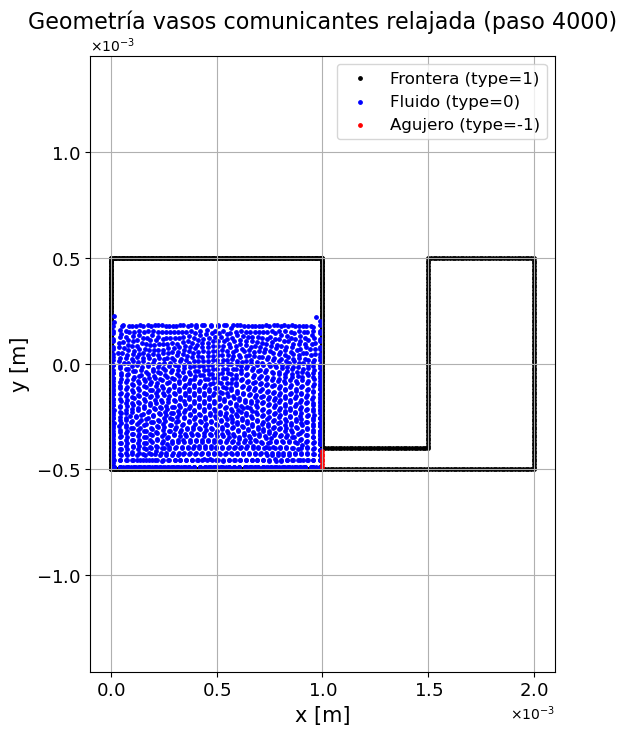

In [3]:
from Config.utils.plot_ics import plot_ics

COMGLASSES_PATH = f"{PROJECT_ROOT}/Output/Comunicated_Glasses"
ESTAB_COMGLASSES = f"{COMGLASSES_PATH}/Estab_Comunicated_Glasses_40x401e-3/Output"
F_ESTAB_FILE = f"{ESTAB_COMGLASSES}/state_3999.txt"

plot_ics(F_ESTAB_FILE, title="Geometría vasos comunicantes relajada (paso 4000)")

2. El vaciado de tanque en el otro vaso comunicante ocurre en tres simulaciones luego de abrir la compuerta, ejecutando 30k pasos en cada una de ellas lo que corresponde a 90k pasos. Lo que hace que el estudio de las superficies libres en cada vaso en un 20% sea en el paso 18k de la primera simulación, mientras la del 50% en el paso 15k de la segunda simulación.

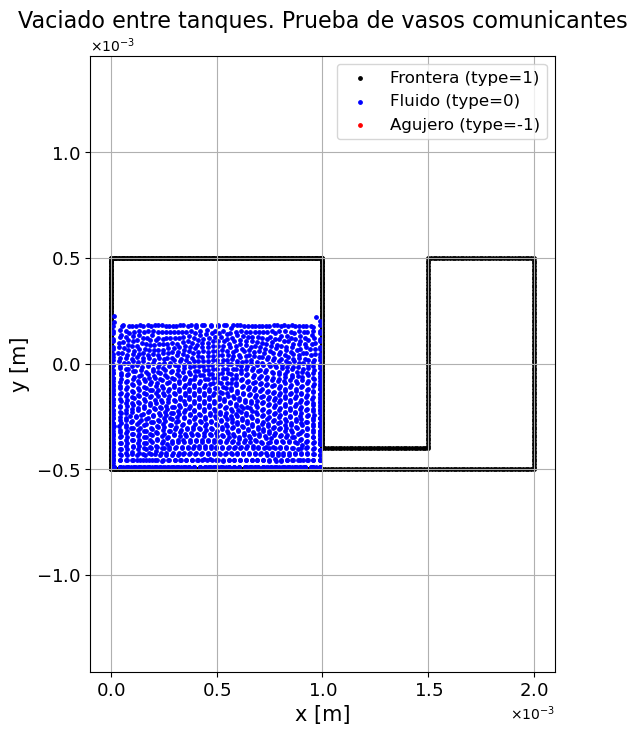

In [3]:
from Config.utils.plot_ics import plot_ics

COMGLASSES_PATH = f"{PROJECT_ROOT}/Output/Comunicated_Glasses"
VAC_COMGLASSES1 = f"{COMGLASSES_PATH}/Open_comunicated_Glasses_40x401e-3/Output"
VAC_COMGLASSES2 = f"{COMGLASSES_PATH}/P2_OpenComGlasses_40x401e-3/Output"
VAC_COMGLASSES3 = f"{COMGLASSES_PATH}/P3_OpenComGlasses_40x401e-3/Output"

INIT_VAC_FILE = f"{VAC_COMGLASSES1}/state_0001.txt"

plot_ics(INIT_VAC_FILE,
         title="Vaciado entre tanques. Prueba de vasos comunicantes")

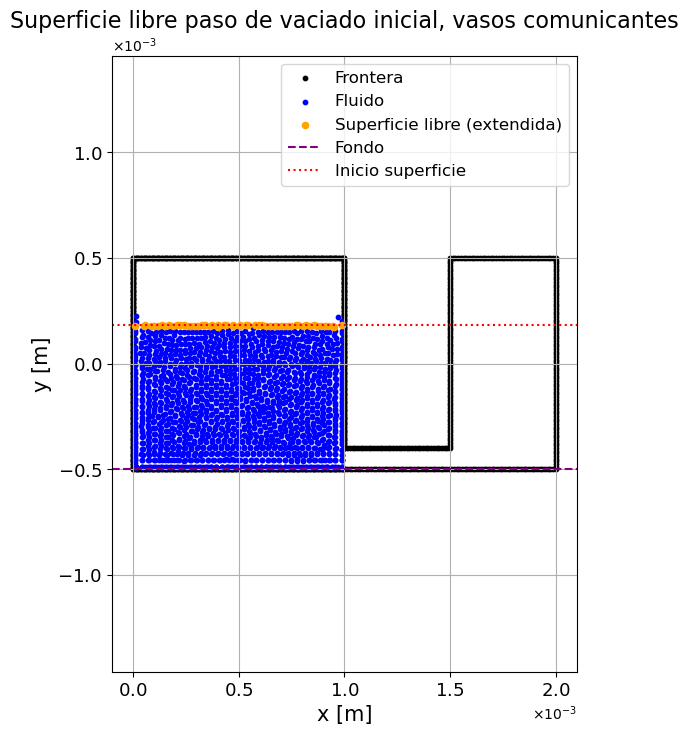

In [4]:
from Analysis.utils.com_glasses_calculus import detectar_superficie_libre

resultado0p = detectar_superficie_libre(
    archivo_txt=INIT_VAC_FILE,
    intervalo_x=(0,1e-3),
    delta_rel=0.01,
    dy_extra_rel=0.01,
    title="Superficie libre paso de vaciado inicial, vasos comunicantes"
)

In [5]:
altura_0p = resultado0p["altura_fluido"]
df_part_0p = resultado0p["df_superficie"]

print(f"La altura del fluido en este paso es de {altura_0p:.3e}")
print(len(df_part_0p))

La altura del fluido en este paso es de 6.804e-04
55


In [6]:
mean_pressure_0p = df_part_0p["pressure"].mean()
print(mean_pressure_0p)

0.18263257655818183


## Ahora para el primer 20%

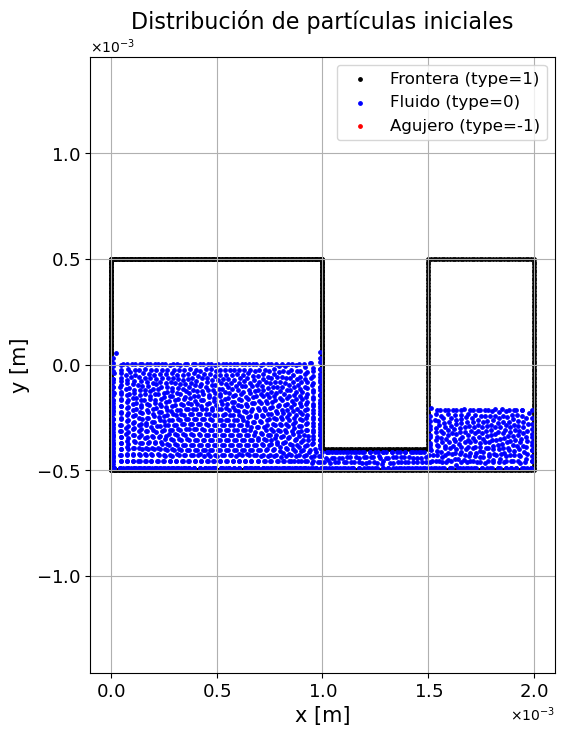

In [7]:
from Config.utils.plot_ics import plot_ics

PP20_VAC_FILE = f"{VAC_COMGLASSES1}/state_17999.txt"

plot_ics(PP20_VAC_FILE)

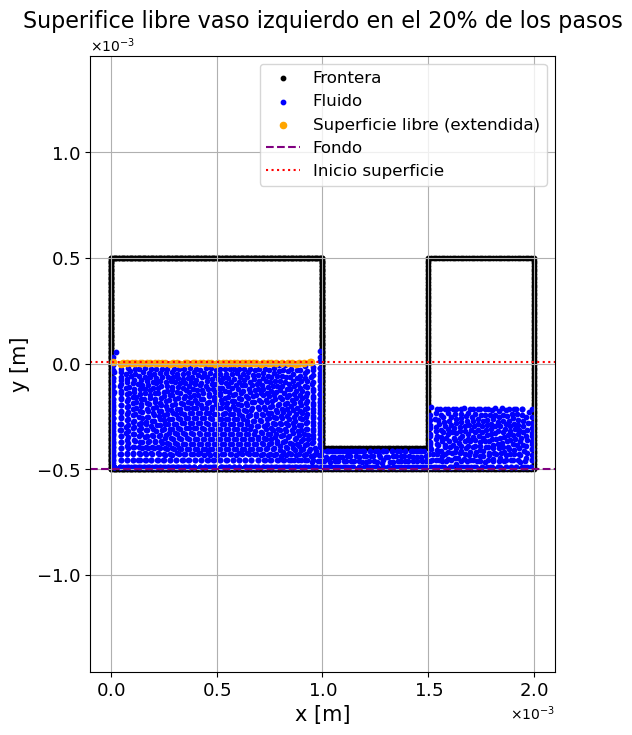

In [8]:
from Analysis.utils.com_glasses_calculus import detectar_superficie_libre

resultado20p_int1 = detectar_superficie_libre(
    archivo_txt=PP20_VAC_FILE,
    intervalo_x=(0,1e-3),
    delta_rel=0.01,
    dy_extra_rel=0.01,
    title="Superifice libre vaso izquierdo en el 20% de los pasos"
)

In [9]:
altura_sup1 = resultado20p_int1["altura_fluido"]
df_part_sup1 = resultado20p_int1["df_superficie"]

print(f"La altura del fluido en este paso es de {altura_sup1:.3e}")
print(len(df_part_sup1))

La altura del fluido en este paso es de 5.027e-04
51


In [10]:
mean_pressure_sup1 = df_part_sup1["pressure"].mean()
print(mean_pressure_sup1)

0.15961199797843137


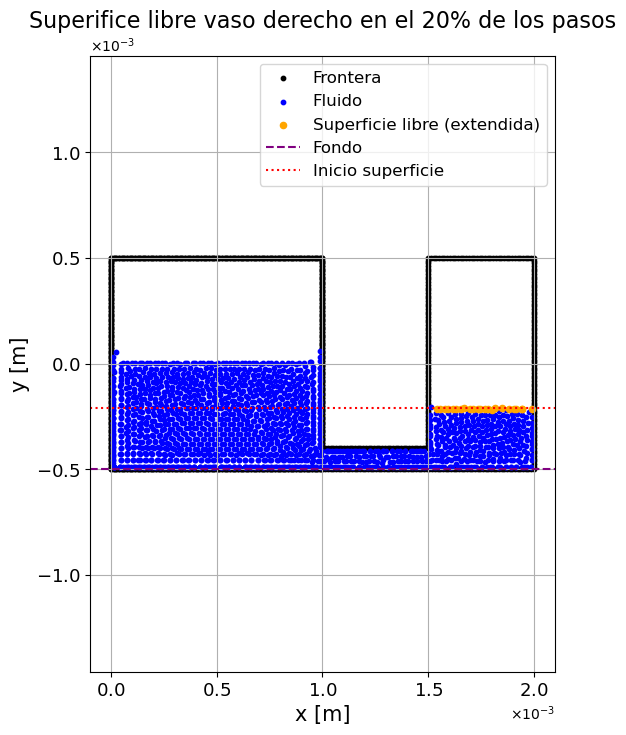

In [11]:
from Analysis.utils.com_glasses_calculus import detectar_superficie_libre

resultado20p_int2 = detectar_superficie_libre(
    archivo_txt=PP20_VAC_FILE,
    intervalo_x=(1.5e-3,2e-3),
    delta_rel=0.01,
    dy_extra_rel=0.01,
    title="Superifice libre vaso derecho en el 20% de los pasos"
)

In [12]:
altura_sup2 = resultado20p_int2["altura_fluido"]
df_part_sup2 = resultado20p_int2["df_superficie"]

print(f"La altura del fluido en este paso es de {altura_sup2:.3e}")
print(len(df_part_sup2))

La altura del fluido en este paso es de 2.866e-04
23


In [13]:
mean_pressure_sup2 = df_part_sup2["pressure"].mean()
print(mean_pressure_sup2)

0.16546323455217388


## El 50%

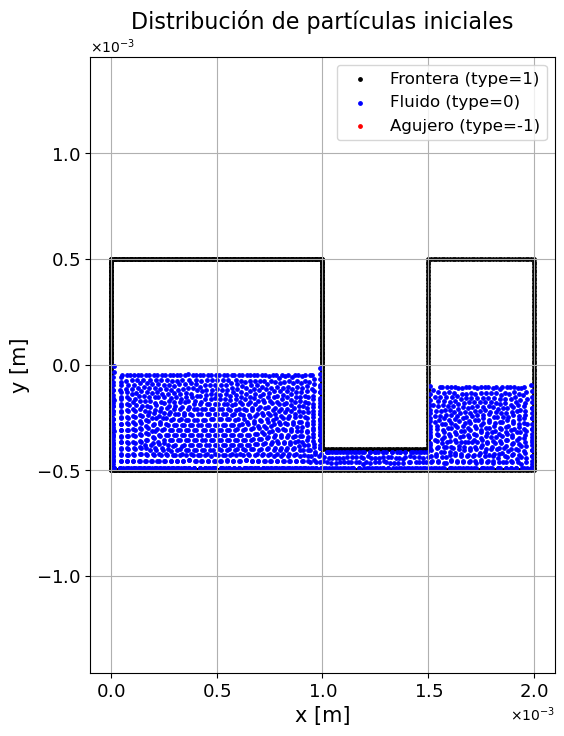

In [14]:
from Config.utils.plot_ics import plot_ics

PP50_VAC_FILE = f"{VAC_COMGLASSES2}/state_14999.txt"

plot_ics(PP50_VAC_FILE)

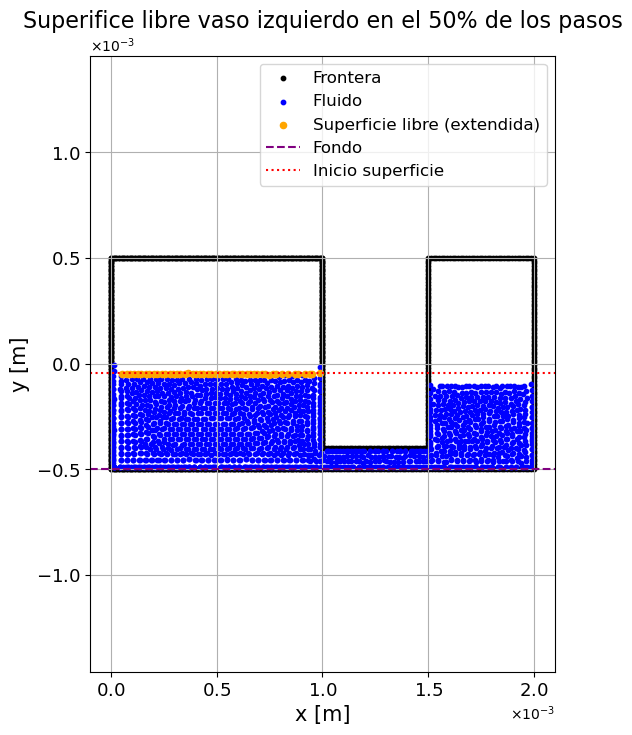

In [15]:
from Analysis.utils.com_glasses_calculus import detectar_superficie_libre

resultado50p_int1 = detectar_superficie_libre(
    archivo_txt=PP50_VAC_FILE,
    intervalo_x=(0,1e-3),
    delta_rel=0.01,
    dy_extra_rel=0.01,
    title="Superifice libre vaso izquierdo en el 50% de los pasos"
)

In [16]:
altura_sup1_p50 = resultado50p_int1["altura_fluido"]
df_part_sup1_p50 = resultado50p_int1["df_superficie"]

print(f"La altura del fluido en este paso es de {altura_sup1_p50:.3e}")
print(len(df_part_sup1_p50))

La altura del fluido en este paso es de 4.518e-04
49


In [17]:
mean_pressure_sup1_p50 = df_part_sup1_p50["pressure"].mean()
print(mean_pressure_sup1_p50)

0.15054991078571428


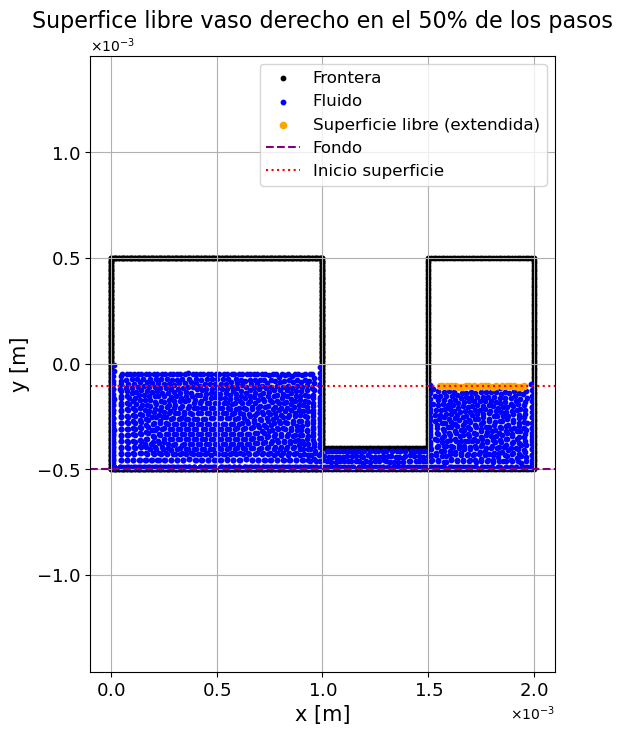

In [18]:
from Analysis.utils.com_glasses_calculus import detectar_superficie_libre

resultado50p_int2 = detectar_superficie_libre(
    archivo_txt=PP50_VAC_FILE,
    intervalo_x=(1.5e-3,2e-3),
    delta_rel=0.01,
    dy_extra_rel=0.01,
    title="Superfice libre vaso derecho en el 50% de los pasos"
)

In [19]:
altura_sup2_p50 = resultado50p_int2["altura_fluido"]
df_part_sup2_p50 = resultado50p_int2["df_superficie"]

print(f"La altura del fluido en este paso es de {altura_sup2_p50:.3e}")
print(len(df_part_sup2_p50))

La altura del fluido en este paso es de 3.928e-04
23


In [20]:
mean_pressure_sup2_p50 = df_part_sup2_p50["pressure"].mean()
print(mean_pressure_sup2_p50)

0.14137579533913042


## Para 100% (90k pasos) = 4.5 s de tiempo de simulación.

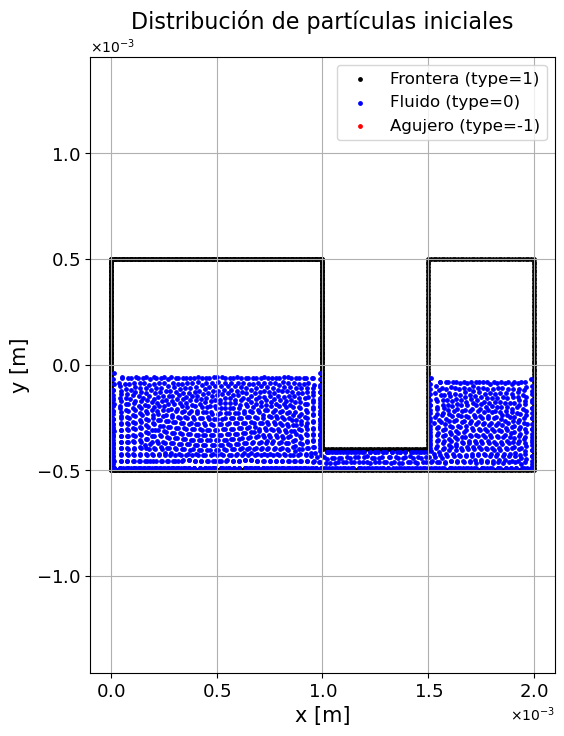

In [21]:
from Config.utils.plot_ics import plot_ics

PP100_VAC_FILE = f"{VAC_COMGLASSES3}/state_29999.txt"

plot_ics(PP100_VAC_FILE)

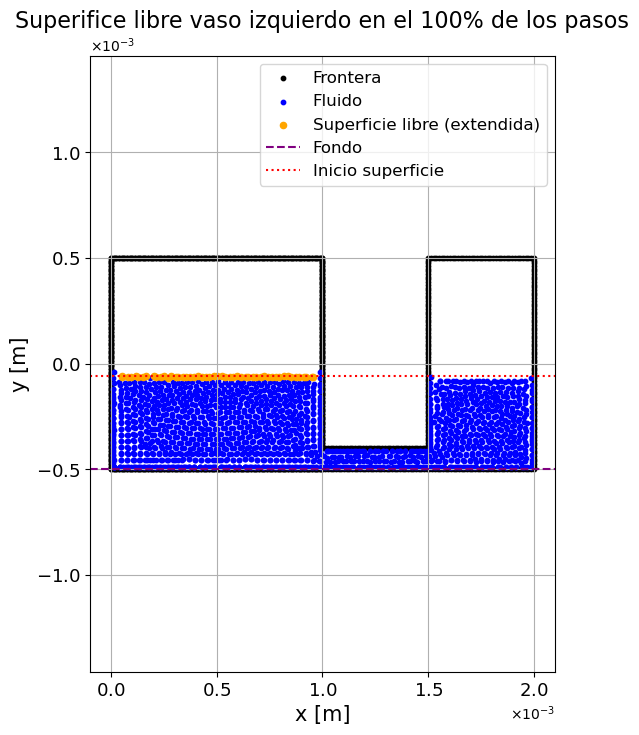

In [22]:
from Analysis.utils.com_glasses_calculus import detectar_superficie_libre

resultado100p_int1 = detectar_superficie_libre(
    archivo_txt=PP100_VAC_FILE,
    intervalo_x=(0,1e-3),
    delta_rel=0.01,
    dy_extra_rel=0.01,
    title="Superifice libre vaso izquierdo en el 100% de los pasos"
)

In [23]:
altura_sup1_p100 = resultado100p_int1["altura_fluido"]
df_part_sup1_p100 = resultado100p_int1["df_superficie"]

print(f"La altura del fluido en este paso es de {altura_sup1_p100:.3e}")
print(len(df_part_sup1_p100))

La altura del fluido en este paso es de 4.388e-04
51


In [24]:
mean_pressure_sup1_p100 = df_part_sup1_p100["pressure"].mean()
print(mean_pressure_sup1_p100)

0.14411388781764706


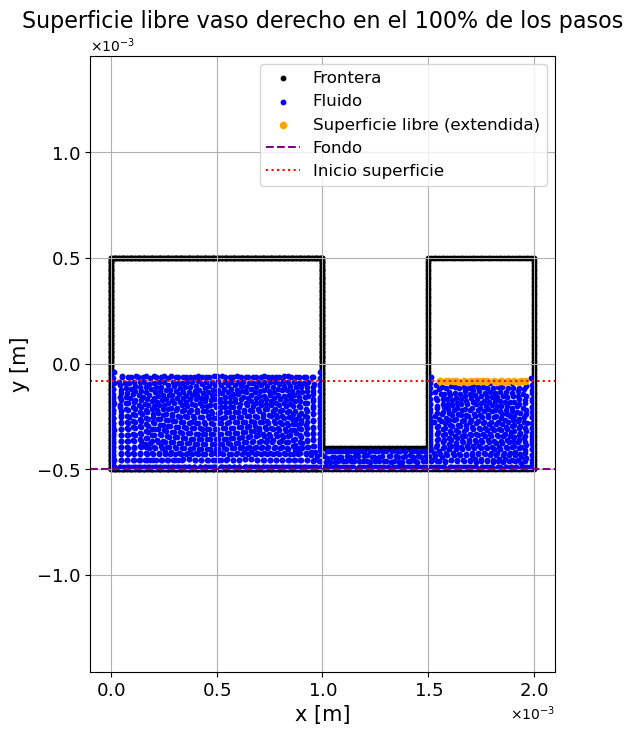

In [25]:
from Analysis.utils.com_glasses_calculus import detectar_superficie_libre

resultado100p_int2 = detectar_superficie_libre(
    archivo_txt=PP100_VAC_FILE,
    intervalo_x=(1.5e-3,2e-3),
    delta_rel=0.01,
    dy_extra_rel=0.01,
    title="Superficie libre vaso derecho en el 100% de los pasos"
)

In [26]:
altura_sup2_p100 = resultado100p_int2["altura_fluido"]
df_part_sup2_p100 = resultado100p_int2["df_superficie"]

print(f"La altura del fluido en este paso es de {altura_sup2_p100:.3e}")
print(len(df_part_sup2_p100))

La altura del fluido en este paso es de 4.173e-04
23


In [27]:
mean_pressure_sup2_p100 = df_part_sup2_p100["pressure"].mean()
print(mean_pressure_sup2_p100)

0.15272456819565217


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import numpy as np


def plot_colormap_fluido(
    archivo_txt,
    campo="pressure",
    title=None,
    colorbar_label=None,
    particle_size_fluido=10,
    particle_size_frontera=8,
    cmap="viridis",
    xlim=None,
    ylim=None,
    mostrar=True,
    # --- parámetros de clipping ---
    n_min_color=10,
    dp_rel=0.01,
    usar_clipping=True,
    debug=False
):
    """
    Grafica un colormap del fluido (type=0) y superpone la frontera (type=1),
    evitando outliers en la escala de color mediante un criterio de densidad.
    """

    # --------------------------------------------------
    # 1. Leer datos
    # --------------------------------------------------
    df = pd.read_csv(archivo_txt, sep=r"\s+")

    df_fluido = df[df["type"] == 0]
    df_frontera = df[df["type"] == 1]

    if campo not in df_fluido.columns:
        raise ValueError(f"El campo '{campo}' no existe en el archivo.")

    valores = df_fluido[campo].values

    # --------------------------------------------------
    # 2. Determinar rango de color (robusto)
    # --------------------------------------------------
    vmin = np.min(valores)
    vmax = np.max(valores)

    if usar_clipping:
        valores_ord = np.sort(valores)[::-1]
        vmax_robusto = None

        for i in range(len(valores_ord)):
            v_ref = valores_ord[i]
            dp = dp_rel * abs(v_ref)

            banda = valores[
                (valores <= v_ref) &
                (valores >= v_ref - dp)
            ]

            if debug:
                print(
                    f"i={i:3d}, v_ref={v_ref:.3e}, "
                    f"dp={dp:.3e}, n={len(banda)}"
                )

            if len(banda) >= n_min_color:
                vmax_robusto = v_ref
                break

        if vmax_robusto is not None:
            vmax = vmax_robusto

    # --------------------------------------------------
    # 3. Figura
    # --------------------------------------------------
    fig, ax = plt.subplots(figsize=(6, 4))

    ax.scatter(
        df_frontera["posx"],
        df_frontera["posy"],
        c="black",
        s=particle_size_frontera,
        alpha=0.5,
        label="Frontera"
    )

    sc = ax.scatter(
        df_fluido["posx"],
        df_fluido["posy"],
        c=df_fluido[campo],
        cmap=cmap,
        s=particle_size_fluido,
        vmin=vmin,
        vmax=vmax,
        label="Fluido"
    )

    # --------------------------------------------------
    # 4. Barra de color
    # --------------------------------------------------
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(
        colorbar_label if colorbar_label is not None else campo,
        fontsize=12
    )
    cbar.ax.tick_params(labelsize=13)

    # --------------------------------------------------
    # 5. Estética (MISMA que plot_ics)
    # --------------------------------------------------
    ax.set_xlabel("x [m]", fontsize=12)
    ax.set_ylabel("y [m]", fontsize=12)
    ax.set_aspect("equal", adjustable="datalim")

    if title is not None:
        ax.set_title(title, fontsize=16)

    ax.tick_params(axis="both", which="major", labelsize=13)
    ax.grid(True)

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

    plt.tight_layout(rect=[0, 0, 1, 0.92])

    if mostrar:
        plt.show()

    return {
        "vmin": vmin,
        "vmax": vmax,
        "vmax_real": np.max(valores),
        "campo": campo,
        "colorbar_label": colorbar_label or campo
    }


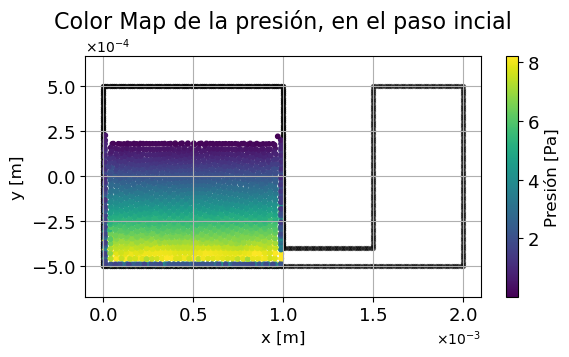

{'vmin': np.float64(0.0075180278),
 'vmax': np.float64(8.2148122028),
 'vmax_real': np.float64(26.6873184519),
 'campo': 'pressure',
 'colorbar_label': 'Presión [Pa]'}

In [35]:
# Gráfica paso 0

plot_colormap_fluido(
    INIT_VAC_FILE,
    title="Color Map de la presión, en el paso incial",
    colorbar_label="Presión [Pa]"
    )

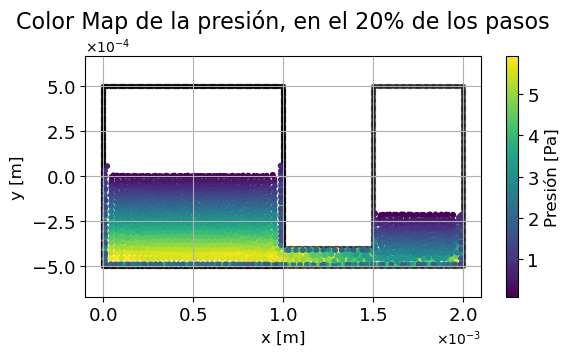

{'vmin': np.float64(0.0927531001),
 'vmax': np.float64(5.9244527386),
 'vmax_real': np.float64(11.8240308862),
 'campo': 'pressure',
 'colorbar_label': 'Presión [Pa]'}

In [36]:
# Vaciado 20%

plot_colormap_fluido(
    PP20_VAC_FILE,
    title="Color Map de la presión, en el 20% de los pasos",
    colorbar_label="Presión [Pa]"
    )

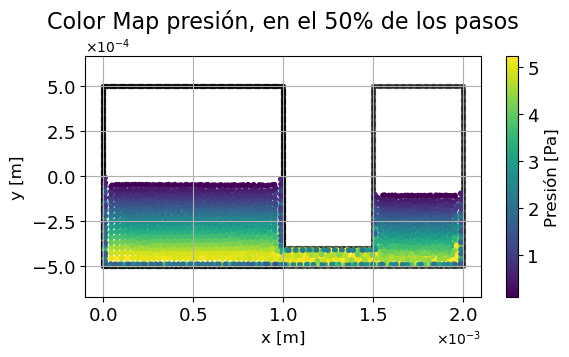

{'vmin': np.float64(0.1042384587),
 'vmax': np.float64(5.2306621553),
 'vmax_real': np.float64(12.0292614232),
 'campo': 'pressure',
 'colorbar_label': 'Presión [Pa]'}

In [37]:
# Vaciado 50%

plot_colormap_fluido(
    PP50_VAC_FILE,
    title="Color Map presión, en el 50% de los pasos",
    colorbar_label="Presión [Pa]"
    )

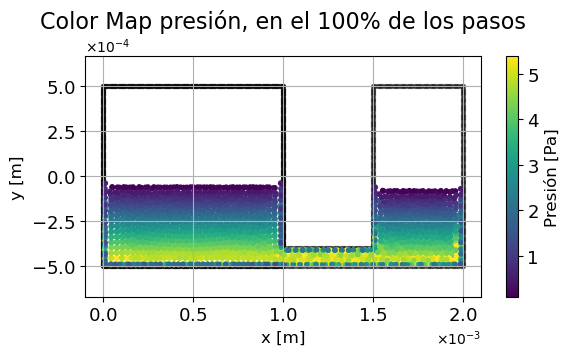

{'vmin': np.float64(0.1000343954),
 'vmax': np.float64(5.3902196771),
 'vmax_real': np.float64(11.6986824322),
 'campo': 'pressure',
 'colorbar_label': 'Presión [Pa]'}

In [38]:
# Vaciado 100%

plot_colormap_fluido(
    PP100_VAC_FILE,
    title="Color Map presión, en el 100% de los pasos",
    colorbar_label="Presión [Pa]")